## CLMT 5053; Comp Research Final

### Scientific Research Question 
How do the two generations of GCM (CMIP6 & CMIP5) compare to the RCM Cordex-Africa in representing annual max temperatures (TX) in near term (2021-2040), high emissions scenarios (SSP5-8.5), specifically over IPCC bounds for South-Eastern Africa (SE-AF)?

### Hypothesis
GCMs CMIP6 and CMIP5 will have a coarser and warmer projected annual maximum temperature (TX) bias over SE-Africa compared to RCM CORDEX-Africa. CMIP6 shows improvement over CMIP5 due to model advancements, while CORDEX Africa will capture even finer spatial variability in TX due to its high regional resolution.  

### Dataset

Data for *CMIP6*, *CMIP5*, *CORDEX-Africa* are sourced from **IPCC WGI Interactive Atlas** as NetCDF files

-----

### Loading / Inspecting Files

In [4]:
import xarray as xr
import zipfile

# Unzipping the files
with zipfile.ZipFile('CMIP5_tx.zip', 'r') as z:
    z.extractall('data/CMIP5/')

with zipfile.ZipFile('CMIP6_tx.zip', 'r') as z:
    z.extractall('data/CMIP6/')

with zipfile.ZipFile('CORDEX_tx.zip', 'r') as z:
    z.extractall('data/CORDEX/')

ds_cmip5 = xr.open_dataset('data/CMIP5/map.nc')
ds_cmip6 = xr.open_dataset('data/CMIP6/map.nc')
ds_cordex = xr.open_dataset('data/CORDEX/map.nc')

In [10]:
ds_cmip6

<xarray.Dataset> Size: 264kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    crs      |S1 1B ...
    tasmax   (lat, lon) float32 259kB ...
Attributes:
    Conventions:     CF-1.5
    Origin:          NetCDF file created by loadeR.2nc: https://github.com/Sa...
    R_package_desc:  loadeR-v1.7.1
    R_package_ref:   https://doi.org/10.1016/j.envsoft.2018.09.009
    R_package_URL:   https://github.com/SantanderMetGroup/loadeR
    GDAL:            GDAL 1.11.4, released 2016/01/25
    history:         Wed May 13 17:06:19 2026: GDAL CreateCopy( /tmp/NETCDF__...

In [9]:
ds_cmip5

<xarray.Dataset> Size: 132kB
Dimensions:  (lat: 90, lon: 180)
Coordinates:
  * lat      (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 1kB -179.0 -177.0 -175.0 -173.0 ... 175.0 177.0 179.0
Data variables:
    crs      |S1 1B ...
    tasmax   (lat, lon) float64 130kB ...
Attributes:
    Conventions:     CF-1.5
    Origin:          NetCDF file created by loadeR.2nc: https://github.com/Sa...
    R_package_desc:  loadeR-v1.7.0
    R_package_ref:   https://doi.org/10.1016/j.envsoft.2018.09.009
    R_package_URL:   https://github.com/SantanderMetGroup/loadeR
    GDAL:            GDAL 1.11.4, released 2016/01/25
    history:         Wed May 13 17:06:38 2026: GDAL CreateCopy( /tmp/NETCDF__...

In [11]:
ds_cordex

<xarray.Dataset> Size: 251kB
Dimensions:  (lat: 179, lon: 173)
Coordinates:
  * lat      (lat) float64 1kB -46.25 -45.75 -45.25 -44.75 ... 41.75 42.25 42.75
  * lon      (lon) float64 1kB -25.25 -24.75 -24.25 -23.75 ... 59.75 60.25 60.75
Data variables:
    crs      |S1 1B ...
    tasmax   (lat, lon) float64 248kB ...
Attributes:
    Conventions:     CF-1.5
    Origin:          NetCDF file created by loadeR.2nc: https://github.com/Sa...
    R_package_desc:  loadeR-v1.7.0
    R_package_ref:   https://doi.org/10.1016/j.envsoft.2018.09.009
    R_package_URL:   https://github.com/SantanderMetGroup/loadeR
    updated_anom:    Done
    GDAL:            GDAL 1.11.4, released 2016/01/25
    history:         Wed May 13 17:06:52 2026: GDAL CreateCopy( /tmp/NETCDF__...

- The data is tasmax, geospatial (lat/lon) as expected

### **Fig 1** : Cartopy Map - Array of Models over all of Africa

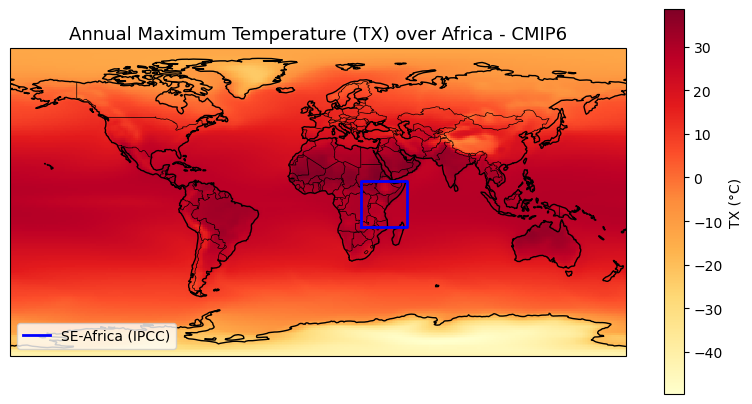

In [14]:
fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

im = ax.pcolormesh(ds_cmip6.lon, ds_cmip6.lat, ds_cmip6.tasmax.values,
                   cmap='YlOrRd', transform=ccrs.PlateCarree())

# Draw SE-Africa bounding box
ax.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        color='blue', linewidth=2, transform=ccrs.PlateCarree(),
        label='SE-Africa (IPCC)')

plt.colorbar(im, ax=ax, orientation='vertical', label='TX (°C)', shrink=0.5)
ax.set_title('Annual Maximum Temperature (TX) over Africa - CMIP6', fontsize=13)
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('fig1_global_cmpi6')
plt.show()

In [13]:
print(ds_cmip5.tasmax.values.min())
print(ds_cmip5.tasmax.values.max())

-49.75177665304864
38.152549338614804


This figure does not directly answer the research question, but provides essential spatial context. CMIP6 was chosen for this overview as it is the most recent of the three models. It shows CMIP6 (most recent model) annual maximum temperatures (TX) across the continent under the high-emissions scenario (SSP5-8.5) for the near-term period 2021–2040. The blue bounding box marks the IPCC-defined SE-Africa region that all subsequent analysis is confined to.

The broad north–south gradient is immediately visible, hottest in the Sahara and Sahel, cooler across the Congo Basin and into southern Africa. The large-scale pattern is one area where GCMs perform relatively well. Literature notes they are generally successful at reproducing continental-scale temperature gradients (Giannini, Biasutti, and Verstraete, 2008), scuh as that thermal contrast between the Sahara and equatorial regions. The time range chosen is also well-suited to the models' strengths — annual temperature ranges have been found to be consistent with observed reanalysis data, showing particularly good alignment with the ERA-Interim dataset (Vizy and Cook, 2012, p.5752).

However, this map cannot show at its resolution is sub-regional variability driven by complex topography such as the Ethiopian Highlands or the Mozambique coast (Dosio et al., 2021, p.3136). Which is something we will see can and is exemplified in the other model familes.

The relatively coarse native resolution of CMIP-generation models (~100–200 km grid spacing) limits their ability to capture how features like mountain ranges and highland plateaus modulate local temperature. 

This is a key limitation that motivates the inclusion of higher-resolution RCM CORDEX-Africa in subsequent figures. Before we can meaningfully compare how the three models represent TX over SE-Africa, it is worth establishing the differences we are looking for are likely to be subtle regional signals rather than gross errors in the overall temperature field.

### **Fig 2** : 3 Panel Cartopy - mean TX, by model, SE-Africa (pcolormesh)

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt

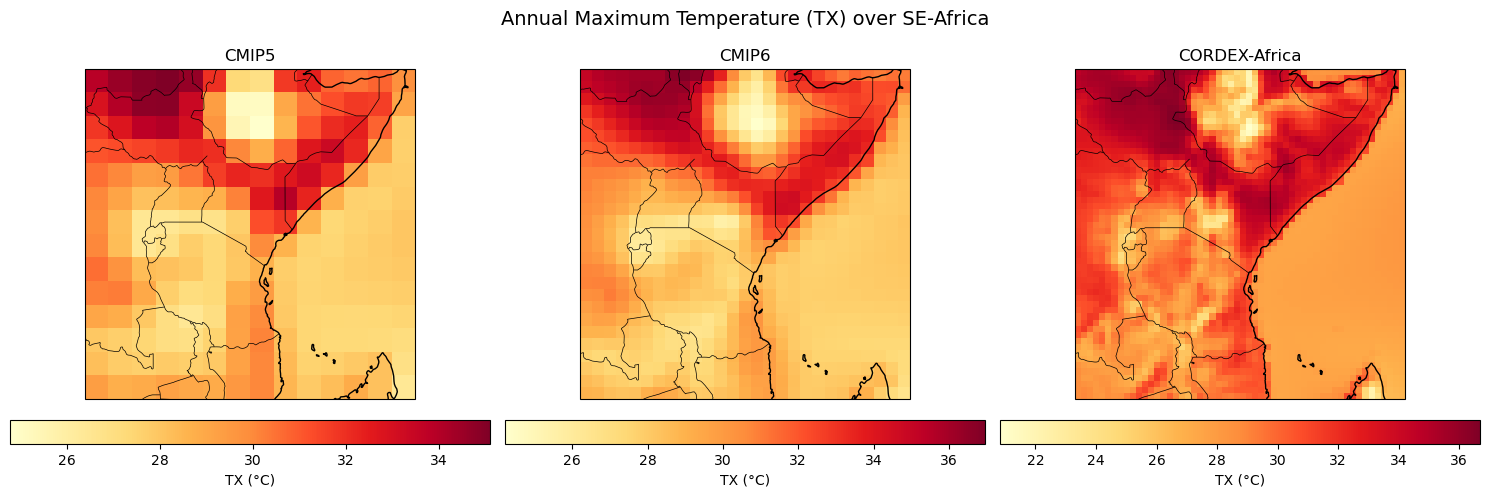

In [49]:
# SE-Africa bounds (IPCC)
lon_min, lon_max = 25, 52
lat_min, lat_max = -15, 12

# Slice datasets to SE-Africa
tx_cmip5 = ds_cmip5.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
tx_cmip6 = ds_cmip6.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
tx_cordex = ds_cordex.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

datasets = [tx_cmip5, tx_cmip6, tx_cordex]
titles = ['CMIP5', 'CMIP6', 'CORDEX-Africa']

for ax, data, title in zip(axes, datasets, titles):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    im = ax.pcolormesh(data.lon, data.lat, data.values,
                       cmap='YlOrRd', transform=ccrs.PlateCarree())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, orientation='horizontal', label='TX (°C)', pad=0.05)

plt.suptitle('Annual Maximum Temperature (TX) over SE-Africa', fontsize=14)
plt.tight_layout()
plt.savefig('fig2_pcolormesh.png')
plt.show()

This figure directly addresses the RQ by showing how each model represents the spatial pattern of TX projected for 2021–2040 over SE-Africa under SSP5-8.5. Placing all three panels side-by-side allows a first visual comparison of where they agree and where they diverge.

The immediate answer this figure offers is CORDEX-Africa gives a notably more detailed TX field compared to both GCM. Resolving finer gradients around the Ethiopian Highlands and East African Rift margins CMIP5 and CMIP6 smooth over. 

This supports the hypothesis that CORDEX-Africa captures finer spatial variability in TX due to its higher resolution.

On the question of CMIP5 vs CMIP6, the two panels look broadly similar at this visual scale, which is itself an informative finding. It suggests generational improvement in CMIP6 may not be dramatically expressed in the spatial pattern of mean TX over this specific region and time period. The more quantitative comparisons in Figs 5–8 explores this further.

### **Fig 3** : 3 Panel Cartopy - mean TX, by model, SE-Africa (contourf)

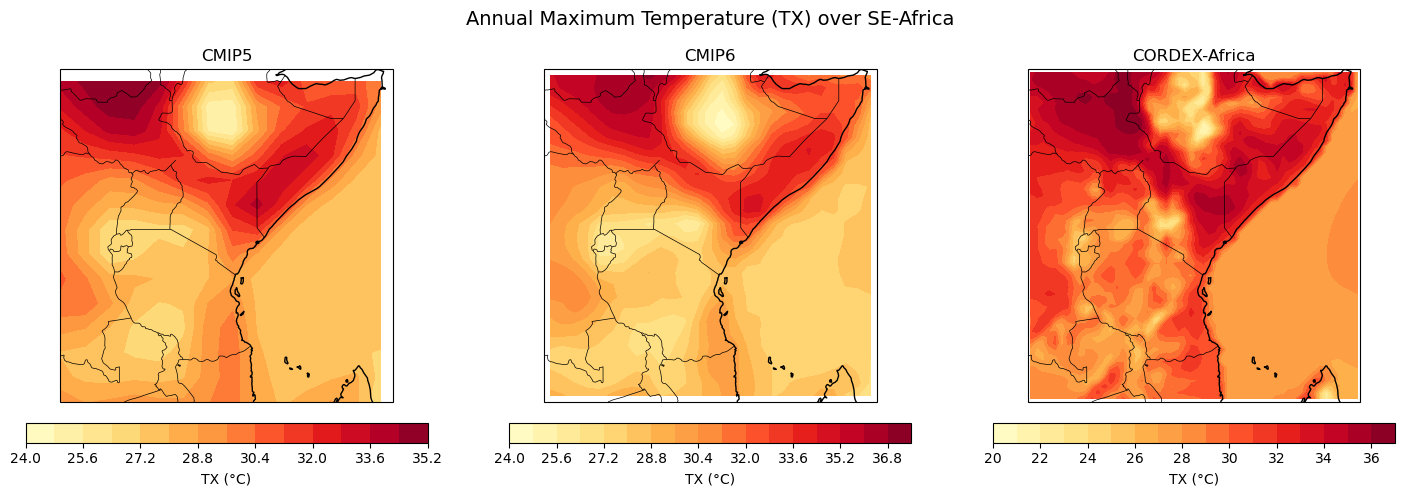

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

datasets = [tx_cmip5, tx_cmip6, tx_cordex]
titles = ['CMIP5', 'CMIP6', 'CORDEX-Africa']

for ax, data, title in zip(axes, datasets, titles):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    im = ax.contourf(data.lon, data.lat, data.values,
                     levels=15, cmap='YlOrRd', transform=ccrs.PlateCarree())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, orientation='horizontal', label='TX (°C)', pad=0.05, shrink=0.8)

plt.suptitle('Annual Maximum Temperature (TX) over SE-Africa', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_contourf.png', dpi=150, bbox_inches='tight')
plt.show()

This figure shows the same data as Fig 2 rendered as a smooth contour field instead of raw grid cells. Interpolating between grid points, contourf makes it easier to compare the spatial structure of the warming signal across models without the visual distraction of CMIP5 and CMIP6's coarser grid boxes.

With that smoothing applied, the three models appear alot more similar than Fig 2 suggested, which is a useful reminder that part of what looks like a difference between CMIP5/CMIP6 and CORDEX-Africa in the pcolormesh plots could be a rendering artefact of resolution, and not necessarily a difference in the underlying temperature signal. 

For answering the research question, this means we should be careful not to over-interpret visual spatial differences as model disagreement; the line plots and statistics in later figures provide a more honest comparison.

### **Fig 4** : Pcolormesh vs Contourf

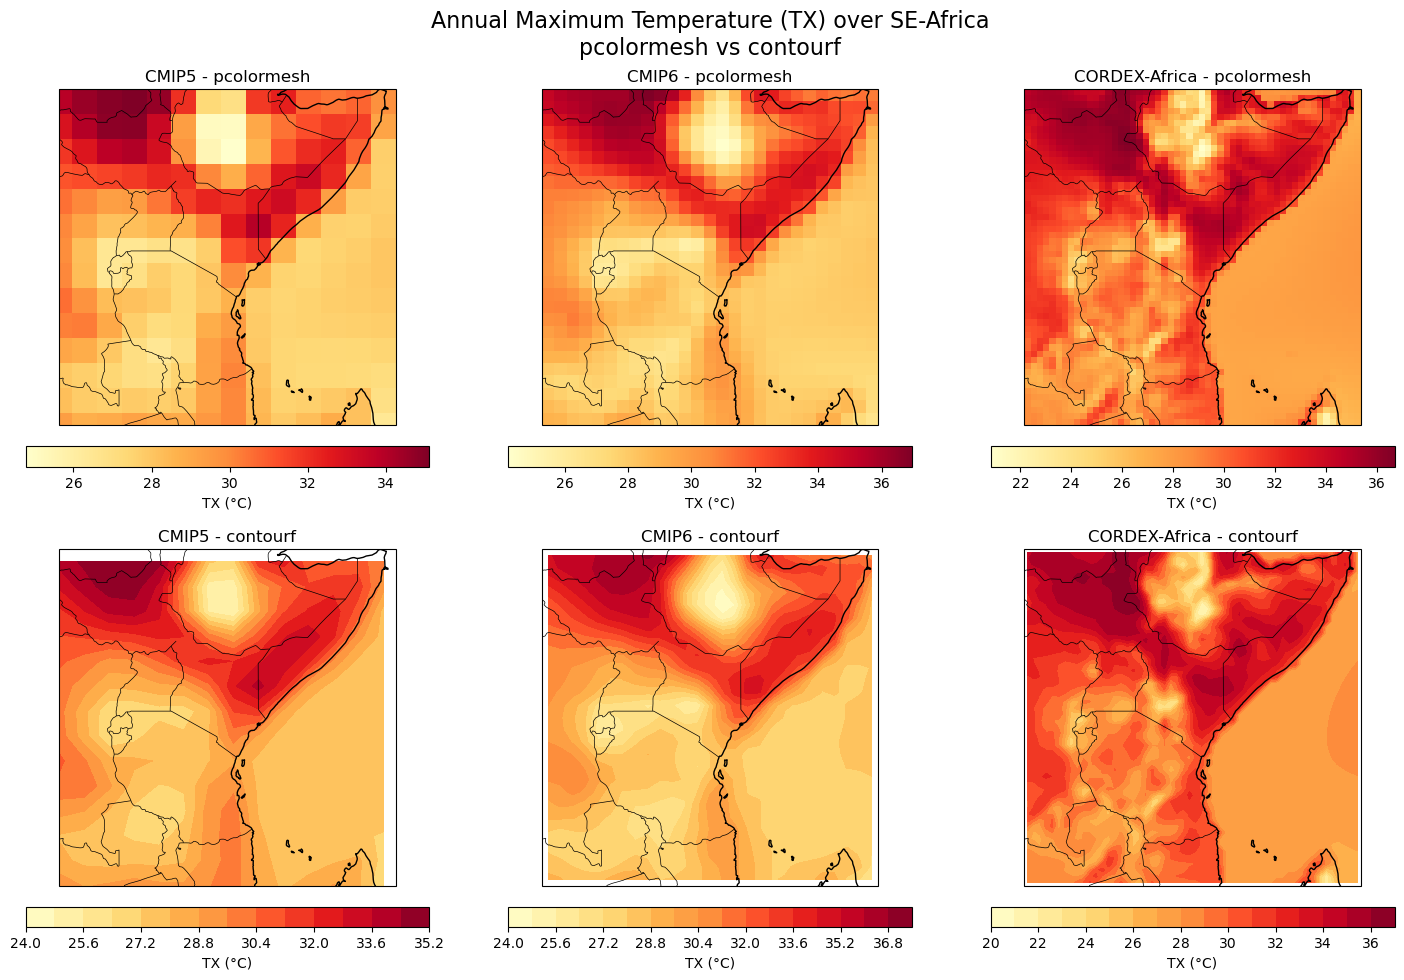

In [47]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})

datasets = [tx_cmip5, tx_cmip6, tx_cordex]
titles = ['CMIP5', 'CMIP6', 'CORDEX-Africa']

# Top row (pcolormesh)
for ax, data, title in zip(axes[0], datasets, titles):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    im = ax.pcolormesh(data.lon, data.lat, data.values,
                       cmap='YlOrRd', transform=ccrs.PlateCarree())
    ax.set_title(f'{title} - pcolormesh')
    plt.colorbar(im, ax=ax, orientation='horizontal', label='TX (°C)', pad=0.05, shrink=0.8)

# Bottom row (contourf)
for ax, data, title in zip(axes[1], datasets, titles):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    im = ax.contourf(data.lon, data.lat, data.values,
                     levels=15, cmap='YlOrRd', transform=ccrs.PlateCarree())
    ax.set_title(f'{title} - contourf')
    plt.colorbar(im, ax=ax, orientation='horizontal', label='TX (°C)', pad=0.05, shrink=0.8)

plt.suptitle('Annual Maximum Temperature (TX) over SE-Africa\npcolormesh vs contourf', fontsize=16)
plt.tight_layout()
plt.savefig('fig4_combined.png', dpi=150, bbox_inches='tight')
plt.show()

This figure helps expound on the latter by placing the pcolormesh vs contourf in the same field of vewi. Its value is in making explicit that the choice of visualisation technique influences how similar or different the three models appear.

For the research question, the key takeaway is that **visual spatial comparison alone is insufficient** to determine how CMIP5, CMIP6, and CORDEX-Africa differ in their representation of TX. 

The resolution gap between the GCMs and CORDEX-Africa means that any pixel-level spatial comparison is comparing models on unequal footing. This is precisely why the analysis pivots to zonal means, meridional means, and distributional statistics in subsequent figures — methods that allow a fairer comparison across different grid resolutions.

**Side note; There is currently no option to download stand alone points via the IPCC Interactiv Atlas, so I can only engage with the lat/lon data initially derived. This is a point that can certianly be taken into account in further for further research and flexibility in data visualization and analysis.

### **Fig X** : 2 Array Panel Cartpoy
1) CMIP6 minus CMIP5
2) CMIP6 minus CORDEX-Africa over SE-AF

In [20]:
# Reslice with new bounds
tx_cmip5 = ds_cmip5.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
tx_cmip6 = ds_cmip6.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
tx_cordex = ds_cordex.tasmax.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Check shapes match
print(tx_cmip5.shape)
print(tx_cmip6.shape)
print(tx_cordex.shape)

(14, 14)
(27, 27)
(54, 54)


Worth noting that I tried to find the difference between models by subtracting. I considered interpolating but was unsure of how to. Kept get an error. Should definetly have tried to come to office hours. 

Given this, I will do a  zonal mean line plot

**Had to pivot a couple of the proposed figures since I cant compare different resolutions

### **Fig 5** : Zonal Mean Line Plot

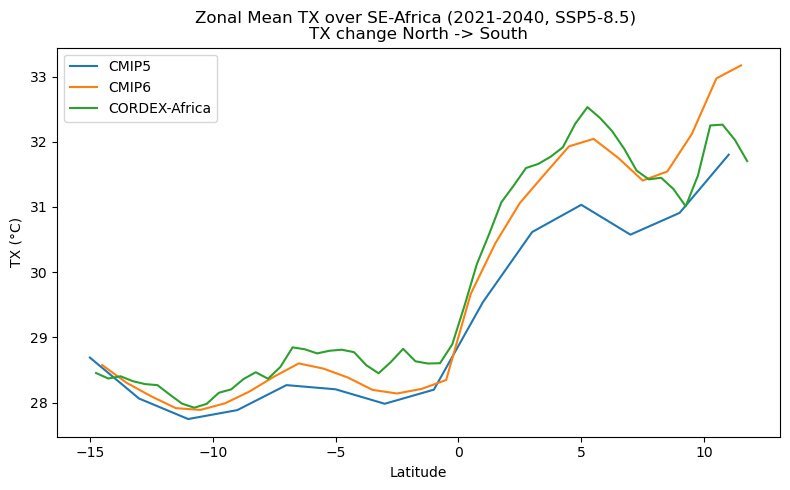

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

tx_cmip5.mean(dim='lon').plot(ax=ax, label='CMIP5')
tx_cmip6.mean(dim='lon').plot(ax=ax, label='CMIP6')
tx_cordex.mean(dim='lon').plot(ax=ax, label='CORDEX-Africa')

ax.set_xlabel('Latitude')
ax.set_ylabel('TX (°C)')
ax.set_title('Zonal Mean TX over SE-Africa (2021-2040, SSP5-8.5) \n'
            'TX change North -> South')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_zonal_mean.png', dpi=150, bbox_inches='tight')
plt.show()

This figure contributes more directly to the research question than the maps. Averaging along longitude give a single comparable value at each latitude regardless of grid resolution, allowing a fairer like-for-like comparison of CMIP5, CMIP6, and CORDEX-Africa along the north–south axis of SE-Africa.

An important limitation: the zonal mean includes both land and ocean cells at each latitude. These surface types engage with temperature very differently. Over land, TX is shaped by topography, vegetation, land use, agriculture, and urban heat effects, none of which apply at sea. This blending limits how precisely inter-model differences can be attributed to land-surface temperature representation, which is ultimately what the research question is concerned with. A land-masked version would produce a cleaner signal.

Despite this, the figure still helps answer the question. Where the three lines diverge, that is genuine model disagreement in TX at that latitude. Larger spread in the north (towards the Sahel) is consistent with the literature finding that model uncertainty is greatest in hotter, arid zones(Vizy and Cook, 2012, p5753). On the CMIP5 vs CMIP6 question, lines sitting close together across most latitudes would suggest CMIP6 has not substantially revised TX projections over SE-Africa for this near-term period. The position of CORDEX-Africa relative to both GCM lines then indicates whether the RCM shifts the mean or simply captures more variability around it.

### **Fig 6** : Meridionial Mean Line Plot

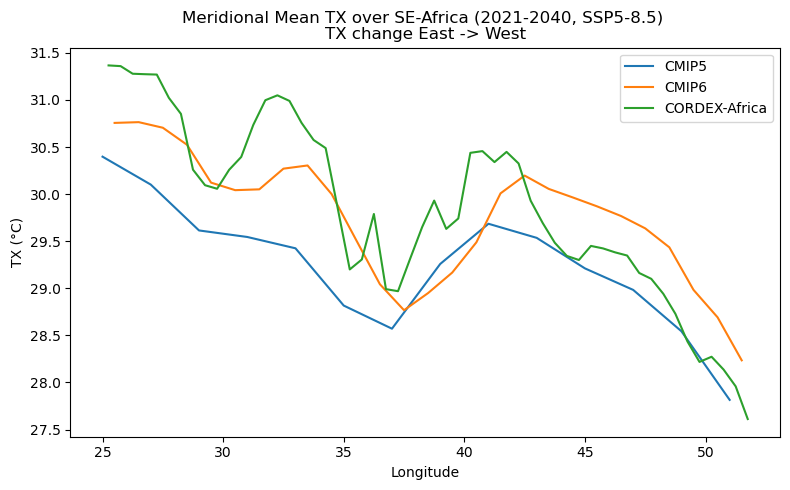

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

tx_cmip5.mean(dim='lat').plot(ax=ax, label='CMIP5')
tx_cmip6.mean(dim='lat').plot(ax=ax, label='CMIP6')
tx_cordex.mean(dim='lat').plot(ax=ax, label='CORDEX-Africa')

ax.set_xlabel('Longitude')
ax.set_ylabel('TX (°C)')
ax.set_title('Meridional Mean TX over SE-Africa (2021-2040, SSP5-8.5) \n'
            'TX change East -> West')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_meridional_mean.png', dpi=150, bbox_inches='tight')
plt.show()

Figure 6 complements Fig 5 by averaging along latitude instead, isolating the east–west temperature gradient from the continental interior toward the Indian Ocean coast. Together, Figs 5 and 6 give a cross-sectional picture of how each model represents TX across both axes of the SE-Africa domain.

The same land-sea limitation from Fig 5 applies here — averaging across full latitudinal bands blends ocean and land cells, diluting the land-surface TX signal the research question is actually concerned with. This is arguably a greater problem for the meridional mean than the zonal mean, since the east–west gradient in SE-Africa is strongly shaped by the Indian Ocean coast, meaning ocean cells have an outsized influence on the eastern longitudes particularly.

This limits how much weight should be placed on inter-model differences when drawing conclusions about TX over land. That said, divergence between CORDEX-Africa and the two GCMs toward the eastern longitudes is likely the RCM resolving the coastal gradient more precisely — consistent with its higher resolution. Differences in the mid-longitude interior are more cleanly attributable to model physics and resolution, and are therefore the more meaningful part of this figure for answering the research question.

### **Fig 7**: Histogram Distribution of TX values

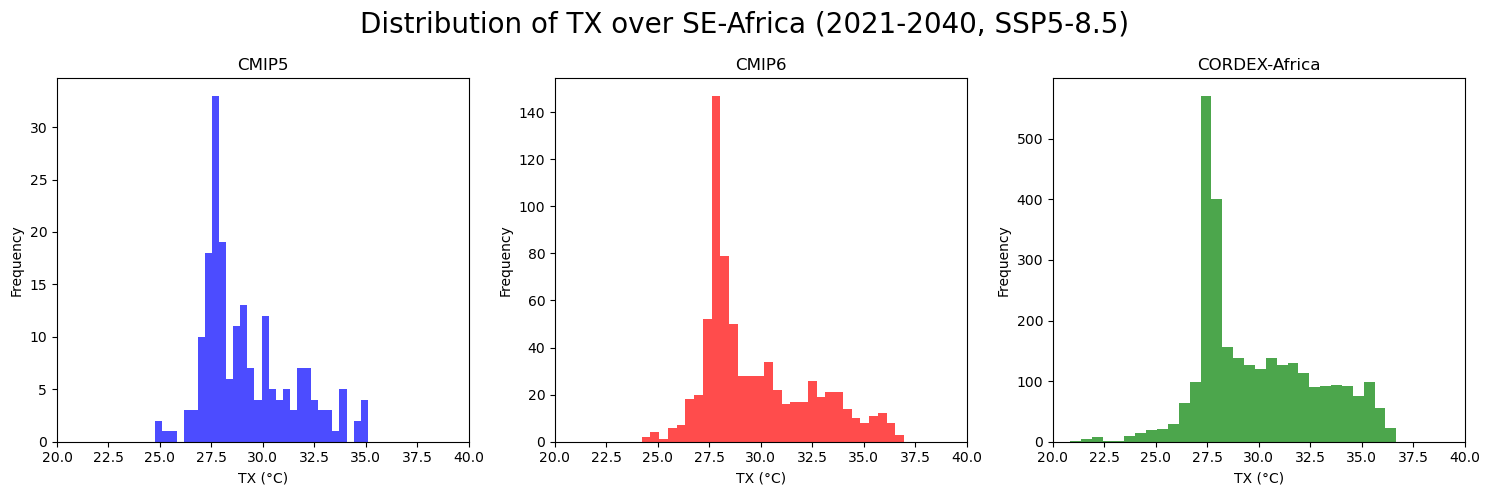

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

datasets = [tx_cmip5, tx_cmip6, tx_cordex]
titles = ['CMIP5', 'CMIP6', 'CORDEX-Africa']
colors = ['blue', 'red', 'green']

for ax, data, title, color in zip(axes, datasets, titles, colors):
    ax.hist(data.values.flatten(), bins=30, color=color, alpha=0.7)
    ax.set_xlabel('TX (°C)')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.set_xlim(20, 40)

plt.suptitle('Distribution of TX over SE-Africa (2021-2040, SSP5-8.5)', fontsize=20)
plt.tight_layout()
plt.savefig('fig7_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

All three models peak at around 28°C, which is the most directly comparable finding across the panels and suggests broad agreement on the central tendency of TX over SE-Africa for this near-term period. However, the distributions differ in important ways that are relevant to the research question.

CMIP5 produces a notably flat, spread-out distribution with low frequencies across a wide temperature range, a consequence of its coarse resolution averaging out local variability into a relatively uniform field. 

CMIP6, despite being a newer generation model, shows a sharper and more tightly peaked distribution than CMIP5, which is somewhat counterintuitive. Both GCMs show a secondary spread into the 30–35°C range, suggesting some grid cells in the hotter, drier interior of the domain are captured even at coarse resolution.

CORDEX-Africa's distribution is the most interesting for the research question. The y-axis frequency is far higher, reflecting its much greater number of grid cells over the same domain, but the shape shows both a sharper peak at ~28°C and a heavier tail extending toward 35–37°C. The tail represents local hot-spots in the interior, such as hyperlocal desert-like or arid climates, that the coarser GCMs smooth over entirely. 

One important caveat: because frequency counts scale with grid cell count, the y-axes are not comparable across panels. The shape and tail behaviour of each distribution matters more than the bar heights when drawing conclusions about model differences.

### **Fig 8** : Bar chart of spatial mean TX per model

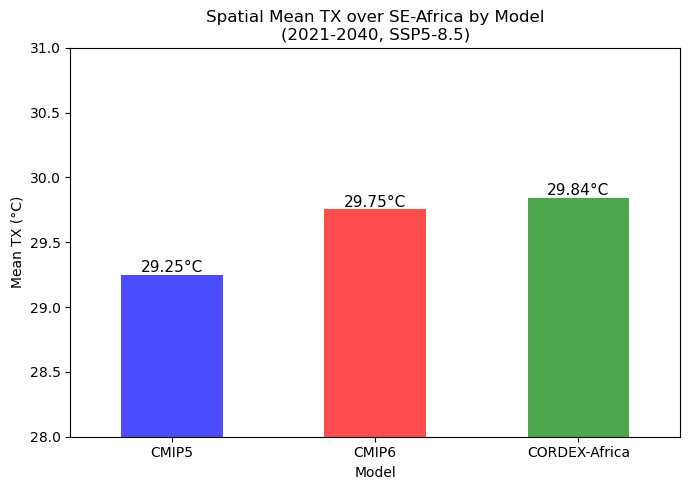

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
s.plot(kind='bar', ax=ax, color=['blue', 'red', 'green'], alpha=0.7)

ax.set_ylabel('Mean TX (°C)')
ax.set_xlabel('Model')
ax.set_title('Spatial Mean TX over SE-Africa by Model\n(2021-2040, SSP5-8.5)')
ax.set_ylim(28, 31)
ax.tick_params(axis='x', rotation=0)

for i, val in enumerate(s.values):
    ax.text(i, val + 0.02, f'{val:.2f}°C', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fig8_bar_mean.png', dpi=150, bbox_inches='tight')
plt.show()

This is the most direct figure to answer the RQ, reducing each model's entire TX field over SE-Africa to a single comparable number. The values are: 
* CMIP5 at 29.25°C
* CMIP6 at 29.75°C
* CORDEX-Africa at 29.84°C.

The 0.5°C step from CMIP5 to CMIP6 is the most notable finding for the GCM comparison, it suggests the newer generation model projects meaningfully warmer mean TX over SE-Africa for this near-term period. 

This is consistent with the literature noting that CMIP6 models tend to have higher climate sensitivity than their CMIP5 predecessors. The gap between CMIP6 and CORDEX-Africa is much smaller at just 0.09°C, suggesting the two agree closely on mean TX despite their very different resolutions.

However, this figure should be interpreted carefully alongside Fig 7. As the histograms showed, CORDEX-Africa produces a much wider distribution with a heavier upper tail, so its spatial mean is being pulled in two directions by cooler ocean and coastal cells on one side and hot interior land cells on the other. 

A near-identical mean to CMIP6 does not mean the two models are representing TX the same way. CORDEX-Africa is averaging over more internal variability to arrive at a similar number.

The land-sea issue is also most visible here. The spatial mean includes all grid cells, land and ocean. So all three values are suppressed somewhat by cooler ocean cells in the domain. This means the true mean TX over land is higher than the numbers shown, and the inter-model differences over land specifically may be larger than the 0.5°C and 0.09°C gaps suggest.

### Conclusion

This study compared CMIP5, CMIP6, and CORDEX-Africa in their representation of annual maximum temperatures (TX) over SE-Africa for the near-term period 2021–2040 under SSP5-8.5.

A key methodological limitation/reflection is that sourcing data as spatial NetCDF files from the IPCC WGI Interactive Atlas, while convenient, constrained the analysis. The format is primarily designed for map visualisation, which is why much of this study is built around spatial plots. The same underlying ensemble mean values are available in more analysis-friendly formats directly from i.e. NASA. This would have allowed for area-weighted spatial means or direct grid-to-grid differencing between models, all of which would have strengthened the conclusions here.

On the findings themselves: all three models broadly agree on the spatial structure and mean TX of the domain, producing spatial means within 0.6°C of each other (CMIP5: 29.25°C, CMIP6: 29.75°C, CORDEX-Africa: 29.84°C). The most meaningful difference is between the two GCM generations — CMIP6 projects 0.5°C warmer mean TX than CMIP5, consistent with CMIP6's generally higher climate sensitivity. Where CORDEX-Africa distinguishes itself is not in the mean but in the distribution, its finer resolution captures a heavier upper tail of TX values representing local hot-spots that both GCMs smooth over. 
- Regarding average warming -> the three models tell a similar story.
- Regarding extremes and local variability -> CORDEX-Africa provides a meaningfully different picture.

### Sources 

Biasutti, Michela. 2019. “Rainfall Trends in the African Sahel: Characteristics, Processes, and Causes.” Wiley Interdisciplinary Reviews: Climate Change 10 (4): e591. https://doi.org/10.1002/wcc.591.

Biasutti, Michela, and Adam H. Sobel. 2009. “Delayed Sahel Rainfall and Global Seasonal Cycle in a Warmer Climate.” Geophysical Research Letters 36 (23). https://doi.org/10.1029/2009gl041303.

Diouf, Ibrahima, Papa Fall, Aissatou Faye, Semou Diouf, Abdou Khadyr Diouf, Mamadou Baïlo Barry, Ansoumana Bodian, and Amadou Sall. 2025. “Assessment of Spatio-Temporal Trends in Rainfall Indices in Senegal: Validation of CMIP6 Models over the Historical Period and Projections under Future Climate Scenarios.” Climate 13 (12): 247. https://doi.org/10.3390/cli13120247.

Vizy, Edward K., and Kerry H. Cook. 2012. “Mid-Twenty-First-Century Changes in Extreme Events over Northern and Tropical Africa.” Journal of Climate 25 (17): 5748–67. https://doi.org/10.1175/jcli-d-11-00693.1.